In [1]:
import pandas as pd
import numpy as np

np.random.seed(99)
n = 1000

# Simulamos una base de clientes de fintech
# En la vida real esto vendría de: pd.read_sql_query("SELECT * FROM clientes", conn)

estados = ["CDMX", "Jalisco", "Nuevo León", "Puebla", "Guanajuato",
           "Veracruz", "Yucatán", "Oaxaca"]

productos = ["Crédito Personal", "Crédito Nómina", "Microcrédito"]

df = pd.DataFrame({
    "cliente_id": range(1001, 2001),
    "edad": np.random.randint(22, 65, n),
    "estado": np.random.choice(estados, n,
              p=[0.30, 0.20, 0.15, 0.10, 0.10, 0.08, 0.04, 0.03]),
    "producto": np.random.choice(productos, n,
                p=[0.50, 0.30, 0.20]),
    "monto_credito": np.random.choice(
        [5000, 10000, 15000, 20000, 30000, 50000], n,
        p=[0.20, 0.25, 0.25, 0.15, 0.10, 0.05]
    ),
    # Días desde su último pago (Recencia)
    "dias_ultimo_pago": np.random.choice(
        [7, 15, 30, 45, 60, 90, 120, 180], n,
        p=[0.20, 0.20, 0.20, 0.15, 0.10, 0.07, 0.05, 0.03]
    ),
    # Número de pagos realizados (Frecuencia)
    "num_pagos": np.random.randint(1, 24, n),
    # Monto total pagado histórico
    "monto_total_pagado": np.random.uniform(1000, 80000, n).round(2),
    # Si el cliente canceló / dejó de pagar (1 = churned, 0 = activo)
    "churn": np.random.choice([0, 1], n, p=[0.72, 0.28]),
    # Días de atraso en su último pago
    "dias_atraso": np.random.choice(
        [0, 0, 0, 5, 10, 15, 30, 60, 90], n,
        p=[0.35, 0.20, 0.15, 0.10, 0.07, 0.05, 0.04, 0.02, 0.02]
    ),
    # Número de productos que tiene con KredMex
    "num_productos": np.random.choice([1, 2, 3], n, p=[0.60, 0.30, 0.10]),
    # Score de riesgo interno (100=sin riesgo, 0=alto riesgo)
    "score_riesgo": np.random.randint(20, 100, n),
})

# Hacemos que el churn tenga correlación real con los datos
# (más realista — clientes con más atraso tienen más churn)
mask_alto_riesgo = (df["dias_atraso"] >= 30) | (df["score_riesgo"] < 40)
df.loc[mask_alto_riesgo, "churn"] = np.random.choice(
    [0, 1], mask_alto_riesgo.sum(), p=[0.30, 0.70]
)

In [2]:
# We visualize the first few rows, summary statistics, and info of the DataFrame
display(df.head())
display(df.describe())
display(df.info())

,cliente_id,edad,estado,producto,monto_credito,dias_ultimo_pago,num_pagos,monto_total_pagado,churn,dias_atraso,num_productos,score_riesgo
0,1001,23,Jalisco,Crédito Personal,15000,15,17,7829.50,0,0,1,98
1,1002,57,Nuevo León,Crédito Personal,15000,15,9,41222.17,0,0,1,68
2,1003,62,CDMX,Crédito Personal,15000,60,21,19311.02,0,0,1,50
3,1004,31,Puebla,Crédito Nómina,10000,60,16,49788.03,1,0,2,70
4,1005,62,Yucatán,Crédito Personal,5000,60,11,27452.35,0,0,1,84


,cliente_id,edad,monto_credito,dias_ultimo_pago,num_pagos,monto_total_pagado,churn,dias_atraso,num_productos,score_riesgo
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1500.500000,43.752000,15230.00000,40.001000,11.931000,39066.986870,0.410000,6.070000,1.488000,58.960000
std,288.819436,12.445376,10126.68009,37.508985,6.577348,23017.012105,0.492079,15.870002,0.672539,23.223474
min,1001.000000,22.000000,5000.00000,7.000000,1.000000,1005.000000,0.000000,0.000000,1.000000,20.000000
25%,1250.750000,33.000000,10000.00000,15.000000,7.000000,19076.727500,0.000000,0.000000,1.000000,38.750000
50%,1500.500000,45.000000,15000.00000,30.000000,12.000000,39464.525000,0.000000,0.000000,1.000000,59.000000
75%,1750.250000,54.250000,20000.00000,45.000000,18.000000,58332.345000,1.000000,5.000000,2.000000,79.000000
max,2000.000000,64.000000,50000.00000,180.000000,23.000000,79887.540000,1.000000,90.000000,3.000000,99.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   cliente_id          1000 non-null   int64  
 1   edad                1000 non-null   int64  
 2   estado              1000 non-null   object 
 3   producto            1000 non-null   object 
 4   monto_credito       1000 non-null   int64  
 5   dias_ultimo_pago    1000 non-null   int64  
 6   num_pagos           1000 non-null   int64  
 7   monto_total_pagado  1000 non-null   float64
 8   churn               1000 non-null   int64  
 9   dias_atraso         1000 non-null   int64  
 10  num_productos       1000 non-null   int64  
 11  score_riesgo        1000 non-null   int64  
dtypes: float64(1), int64(9), object(2)
memory usage: 93.9+ KB


None

In [3]:
#We analyze the correlation of numeric variables with churn
correlacion = df.select_dtypes(include=['int64', 'float64']).corr()["churn"].sort_values(ascending=False)
display(correlacion)



churn                 1.000000
dias_atraso           0.157188
edad                  0.046368
monto_credito         0.044334
num_productos         0.042104
cliente_id            0.038498
monto_total_pagado    0.008866
dias_ultimo_pago     -0.009947
num_pagos            -0.031766
score_riesgo         -0.259417
Name: churn, dtype: float64

In [4]:
#We analyze churn by product type using SQL queries on the DataFrame
import sqlite3
conn = sqlite3.connect(":memory:")
df.to_sql("clientes", conn, index=False, if_exists="replace")
query1 = """SELECT producto, COUNT(*) AS num_clientes,
count(CASE WHEN churn = 1 THEN 1 END) AS num_churned,
ROUND(AVG(churn)*100, 2) AS tasa_churn
FROM clientes GROUP BY producto order BY tasa_churn DESC;"""
results1 = pd.read_sql_query(query1, conn)
display(results1)


,producto,num_clientes,num_churned,tasa_churn
0,Crédito Personal,490,204,41.63
1,Microcrédito,203,83,40.89
2,Crédito Nómina,307,123,40.07


In [5]:
#We analyze churn with respect to different variables using SQL queries on the DataFrame
query2 = """SELECT churn, 
avg(dias_atraso) AS promedio_dias_atraso,
avg(score_riesgo) AS promedio_score_riesgo,
avg(num_pagos) AS promedio_num_pagos,
avg(monto_total_pagado) AS promedio_monto_total_pagado
FROM clientes GROUP BY churn;"""
results2 = pd.read_sql_query(query2, conn)
display(results2)

,churn,promedio_dias_atraso,promedio_score_riesgo,promedio_num_pagos,promedio_monto_total_pagado
0,0,3.991525,63.979661,12.105085,38896.948932
1,1,9.060976,51.736585,11.680488,39311.675610


In [6]:
#We analyze churn by state using SQL queries on the DataFrame
query3 = """SELECT estado, 
COUNT(*) AS num_clientes,
count(CASE WHEN churn = 1 THEN 1 END) AS num_churned,
ROUND(AVG(churn)*100, 2) AS tasa_churn,
rank() OVER (ORDER BY ROUND(AVG(churn)*100, 2) DESC) AS ranking_churn
FROM clientes GROUP BY estado ORDER BY ranking_churn;"""
results3 = pd.read_sql_query(query3, conn)
display(results3)

,estado,num_clientes,num_churned,tasa_churn,ranking_churn
0,Oaxaca,27,14,51.85,1
1,Veracruz,72,32,44.44,2
2,Nuevo León,145,63,43.45,3
3,Puebla,94,39,41.49,4
4,CDMX,299,122,40.80,5
5,Guanajuato,103,41,39.81,6
6,Jalisco,224,87,38.84,7
7,Yucatán,36,12,33.33,8


In [7]:
#We analyze high-risk customers (30+ days late and low risk score) who haven't churned yet using SQL queries on the DataFrame
query4 = """SELECT cliente_id, estado, producto, monto_credito, dias_atraso, score_riesgo
FROM clientes
WHERE dias_atraso >= 30 and score_riesgo < 50 and churn = 0 
ORDER BY dias_atraso DESC;"""
results4 = pd.read_sql_query(query4, conn)
display(results4)

,cliente_id,estado,producto,monto_credito,dias_atraso,score_riesgo
0,1389,Jalisco,Crédito Nómina,15000,90,28
1,1429,Nuevo León,Crédito Nómina,10000,90,21
2,1529,Guanajuato,Crédito Nómina,5000,90,25
3,1468,CDMX,Crédito Nómina,5000,60,26
4,1760,CDMX,Crédito Personal,50000,60,30
5,1776,Nuevo León,Crédito Personal,5000,60,21
6,1040,Guanajuato,Crédito Personal,15000,30,33
7,1170,Jalisco,Crédito Nómina,30000,30,41
8,1354,CDMX,Crédito Personal,15000,30,42
9,1677,CDMX,Crédito Personal,30000,30,44


In [11]:
def clasificar_rfm(row):
     if (row["dias_ultimo_pago"]> 90 or row["dias_atraso"] >= 30 or  row["score_riesgo"] < 40):
         return "CRITICO"
     elif row["dias_ultimo_pago"] >= 31 and row["dias_ultimo_pago"] <= 90 or row["dias_atraso"] >= 5 and  row["dias_atraso"] <= 29:
         return "EN RIESGO"
     elif row["dias_ultimo_pago"] <= 30 and row["num_pagos"] >= 6:
         return "EN DESARROLLO"
     elif row["dias_ultimo_pago"] <= 15 and row["num_pagos"] >= 12 and row["monto_total_pagado"] >= 30000:
         return "CAMPEÓN"   
     else:
         return "OTRO"

df["SEGMENTO"] = df.apply(clasificar_rfm, axis=1)
df["SEGMENTO"].value_counts()

SEGMENTO
CRITICO          376
EN RIESGO        305
EN DESARROLLO    257
OTRO              62
Name: count, dtype: int64

/var/folders/hk/zd_7dr_j5d7gz_djbgkjlb880000gn/T/ipykernel_12855/4056376521.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="SEGMENTO", y="score_riesgo", data=df, ax=axes[1,1], palette="Set2")


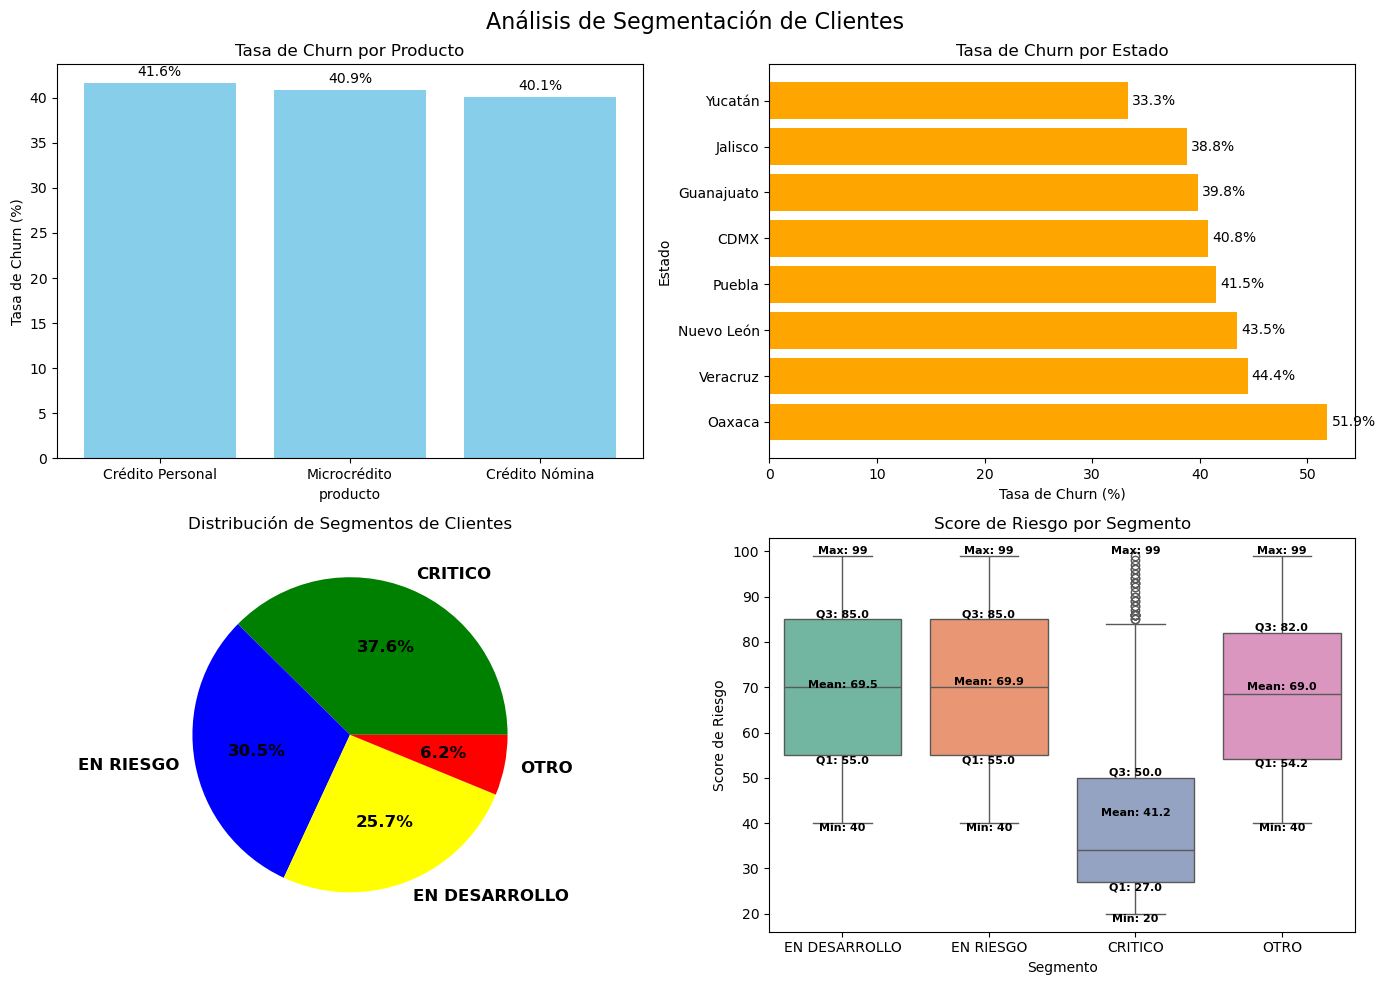

In [9]:
#We generate visualizations for the report
import matplotlib.pyplot as plt
import seaborn as sns   
fig,axes= plt.subplots(2,2,figsize=(14, 10))
fig.suptitle("Análisis de Segmentación de Clientes", fontsize=16)

axes[0,0].bar(results1["producto"], results1["tasa_churn"], color="skyblue")
axes[0,0].set_title("Tasa de Churn por Producto")
axes[0,0].set_xlabel("producto")
axes[0,0].set_ylabel("Tasa de Churn (%)")
for container in axes[0,0].containers:
    axes[0,0].bar_label(container, fmt="%.1f%%", padding=3)


axes[0,1].barh(results3["estado"], results3["tasa_churn"], color="orange")
axes[0,1].set_title("Tasa de Churn por Estado")
axes[0,1].set_xlabel("Tasa de Churn (%)")
axes[0,1].set_ylabel("Estado")
for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt="%.1f%%", padding=3)

axes[1,0].pie(df["SEGMENTO"].value_counts(), labels=df["SEGMENTO"].value_counts().index, autopct="%1.1f%%", colors=["green", "blue", "yellow", "red", "gray"], textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1,0].set_title("Distribución de Segmentos de Clientes")    

sns.boxplot(x="SEGMENTO", y="score_riesgo", data=df, ax=axes[1,1], palette="Set2")
axes[1,1].set_title("Score de Riesgo por Segmento")
axes[1,1].set_ylabel("Score de Riesgo") 
axes[1,1].set_xlabel("Segmento")
#agregamos etiquetas de valores máximos, mínimos, promedio, valor máximo del cuartil superior e inferior
for segment in df["SEGMENTO"].unique():
    segment_data = df[df["SEGMENTO"] == segment]["score_riesgo"]
    max_value = segment_data.max()
    min_value = segment_data.min()
    mean_value = segment_data.mean()
    q1_value = segment_data.quantile(0.25)
    q3_value = segment_data.quantile(0.75)
    axes[1,1].text(df["SEGMENTO"].unique().tolist().index(segment), max_value, f'Max: {max_value}', ha='center', va='bottom', fontsize=8, color='black', fontweight='bold')
    axes[1,1].text(df["SEGMENTO"].unique().tolist().index(segment), min_value, f'Min: {min_value}', ha='center', va='top', fontsize=8, color='black', fontweight='bold')
    axes[1,1].text(df["SEGMENTO"].unique().tolist().index(segment), mean_value, f'Mean: {mean_value:.1f}', ha='center', va='bottom', fontsize=8, color='black', fontweight='bold')
    axes[1,1].text(df["SEGMENTO"].unique().tolist().index(segment), q3_value, f'Q3: {q3_value:.1f}', ha='center', va='bottom', fontsize=8, color='black', fontweight='bold')
    axes[1,1].text(df["SEGMENTO"].unique().tolist().index(segment), q1_value, f'Q1: {q1_value:.1f}', ha='center', va='top', fontsize=8, color='black', fontweight='bold')

plt.tight_layout()
plt.show()

In [10]:
#Export final repor to Excel with visualizations
import io
from openpyxl.drawing.image import Image as XLImage

buffer =io.BytesIO()
fig.savefig(buffer, format="png")
buffer.seek(0)
plt.close()

with pd.ExcelWriter("analisis_clientes_KREDMEX_2.xlsx", engine="openpyxl") as writer:
    results1.to_excel(writer, sheet_name="Churn_por_Producto", index=False)
    results2.to_excel(writer, sheet_name="Promedios_Churn", index=False)
    results3.to_excel(writer, sheet_name="Churn_por_Estado", index=False)
    results4.to_excel(writer, sheet_name="Clientes_En_Riesgo", index=False)
    df.to_excel(writer, sheet_name="Data_completa", index=False)
    
    wb = writer.book
    ws = wb.create_sheet("Dashboard")
    img = XLImage(buffer)
    img.width=950
    img.height=650
    ws.add_image(img, "A1")

print("Análisis completo. Archivo 'analisis_clientes_KREDMEX_2.xlsx' generado con resultados y visualizaciones.")

Análisis completo. Archivo 'analisis_clientes_KREDMEX_2.xlsx' generado con resultados y visualizaciones.
